# Projeto Final: Previsão Simultânea de Ecossistema de Inteligência Artificial (Multi-Output)
**Ativos Analisados:** Microsoft (MSFT), Nvidia (NVDA), Alphabet (GOOGL) e Meta Platforms (META).
**Arquitetura:** Ensemble de Redes Bi-LSTM com Mecanismo de Atenção Cruzada.
**Otimização:** Busca Bayesiana (Optuna).

## Resumo Executivo
O objetivo deste estudo é prever simultaneamente a trajetória de preços do "Quarteto da Inteligência Artificial". Em oposição aos modelos univariados tradicionais, este projeto assume a premissa de que a alta correlação entre empresas de tecnologia exige uma análise ecossistêmica. 

Através de um rigoroso Estudo de Ablação, determinou-se que a janela de observação ideal para este setor é de 20 dias úteis. A matriz de dados conta com 50 variáveis, englobando indicadores técnicos individuais e métricas macroeconômicas (S&P 500 e VIX). A arquitetura preditiva final utiliza uma rede Bi-LSTM otimizada (352 neurônios) acoplada a um Mecanismo de Atenção Temporal (Self-Attention), mitigando o ruído e garantindo um equilíbrio ótimo entre Erro Absoluto (MAPE) e Acurácia Direcional (Hit Rate). Para assegurar a estabilidade estatística e anular a variância de inicialização, o resultado apresentado é a média absoluta de 2.000 modelos independentes.

---
## 1. Configuração do Ambiente e Extração de Dados
Nesta etapa, instanciamos o processamento em GPU e extraímos os dados históricos. A matriz é expandida para acomodar a volatilidade implícita e o momento das quatro ações simultaneamente.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1.1. Configuração de Hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Processamento estocástico iniciado no dispositivo: {device}")

# 1.2. Extração de Dados via API (2019 - 2026)
tickers = ['MSFT', 'NVDA', 'GOOGL', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
ativos = ['MSFT', 'NVDA', 'GOOGL', 'META']

# Isolamento dos Alvos (Targets) nas colunas iniciais da matriz
for ativo in ativos:
    df[f'{ativo}_Close'] = dados['Close'][ativo]

# 1.3. Feature Engineering (Cálculo de Indicadores Técnicos)
for ativo in ativos:
    df[f'{ativo}_Open']   = dados['Open'][ativo]
    df[f'{ativo}_High']   = dados['High'][ativo]
    df[f'{ativo}_Low']    = dados['Low'][ativo]
    df[f'{ativo}_Volume'] = dados['Volume'][ativo]
    
    close_ativo = df[f'{ativo}_Close']
    
    # Suavização de Tendência
    df[f'{ativo}_SMA_20'] = close_ativo.rolling(window=20).mean()
    df[f'{ativo}_EMA_20'] = close_ativo.ewm(span=20, adjust=False).mean()
    
    # Índice de Força Relativa (Momentum)
    delta = close_ativo.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'{ativo}_RSI_14'] = 100 - (100 / (1 + (gain / loss)))
    
    # Convergência e Divergência de Médias Móveis (MACD)
    exp1 = close_ativo.ewm(span=12, adjust=False).mean()
    exp2 = close_ativo.ewm(span=26, adjust=False).mean()
    macd = exp1 - exp2
    df[f'{ativo}_MACD'] = macd
    df[f'{ativo}_MACD_Signal'] = macd.ewm(span=9, adjust=False).mean()
    
    # Volatilidade (Bandas de Bollinger)
    std_20 = close_ativo.rolling(window=20).std()
    df[f'{ativo}_BB_Upper'] = df[f'{ativo}_SMA_20'] + (std_20 * 2)
    df[f'{ativo}_BB_Lower'] = df[f'{ativo}_SMA_20'] - (std_20 * 2)

# 1.4. Inserção Macroeconômica
df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']
df = df.dropna()

QTD_FEATURES = len(df.columns)
QTD_ALVOS = 4

Processamento estocástico iniciado no dispositivo: cuda


---
## 2. Preparação Temporal e Estruturação de Tensores
O modelo avalia a sequência histórica através de uma janela deslizante (Sliding Window). A Busca em Grade prévia determinou que a rede minimiza a Função de Perda de forma mais eficiente ao observar blocos de 20 dias úteis.

In [2]:
# 2.1. Escalonamento de Dados (MinMax)
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

# 2.2. Janela Temporal Otimizada (20 Dias)
seq_len = 20

def criar_sequencias_multi(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        y.append(dados_array[i, 0:QTD_ALVOS]) 
    return np.array(X), np.array(y)

X, y = criar_sequencias_multi(dados_normalizados, seq_len)

# 2.3. Divisão Treino/Teste (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesMultiDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesMultiDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesMultiDataset(X_test, y_test), batch_size=32)

# 2.4. Estrutura para Desnormalização Reversa
matriz_falsa_reais = np.zeros((len(y_test), QTD_FEATURES))
matriz_falsa_reais[:, 0:QTD_ALVOS] = y_test
reais_em_dolar = scaler.inverse_transform(matriz_falsa_reais)[:, 0:QTD_ALVOS]

---
## 3. Definição da Arquitetura de Estado da Arte e Treinamento Massivo
A rede neural emprega o estado bidirecional da LSTM para compreender a causalidade retroativa, mitigando o ruído sistêmico através da Camada de Atenção. Os parâmetros estruturais foram descobertos via Otimização Bayesiana (Optuna). Para certificar a robustez científica dos resultados, executaremos o treinamento independente de 2.000 modelos, fundindo as previsões em uma média absoluta.

In [3]:
# 3.1. A Arquitetura Definitiva (Bi-LSTM + Self-Attention)
class Modelo_Final_Atencao(nn.Module):
    def __init__(self, input_size, hidden_lstm, output_size):
        super(Modelo_Final_Atencao, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True, bidirectional=True)
        # Filtro de relevância temporal dinâmico
        self.attention_weights = nn.Linear(hidden_lstm * 2, 1)
        self.fc = nn.Linear(hidden_lstm * 2, output_size)

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        pesos = self.attention_weights(saida_lstm) 
        pesos = F.softmax(pesos, dim=1)            
        contexto = torch.sum(pesos * saida_lstm, dim=1) 
        return self.fc(contexto)

# 3.2. A Maratona de Treinamento (O Grande Ensemble)
N_RODADAS = 2000 
todas_previsoes_teste = []

print(f"Iniciando Ensemble Massivo: {N_RODADAS} iterações...")
print("Este processo garante a eliminação de viés de inicialização na matriz de pesos.")

for rodada in range(N_RODADAS):
    # Parâmetros Absolutos do Optuna (352 neurônios e LR 0.001130)
    modelo = Modelo_Final_Atencao(
        input_size=QTD_FEATURES, 
        hidden_lstm=352, 
        output_size=QTD_ALVOS
    ).to(device)
    
    optimizer = optim.Adam(modelo.parameters(), lr=0.001130)
    criterion = nn.MSELoss()
    
    modelo.train()
    for epoca in range(50):
        for pacotes_X, pacotes_y in train_loader:
            optimizer.zero_grad()
            previsoes = modelo(pacotes_X.to(device))
            erro = criterion(previsoes, pacotes_y.to(device))
            erro.backward()
            optimizer.step()
            
    modelo.eval()
    previsoes_modelo = []
    with torch.no_grad():
        for pacotes_X, _ in test_loader:
            chute = modelo(pacotes_X.to(device))
            previsoes_modelo.extend(chute.cpu().numpy())
            
    matriz_teste = np.zeros((len(previsoes_modelo), QTD_FEATURES))
    matriz_teste[:, 0:QTD_ALVOS] = previsoes_modelo
    todas_previsoes_teste.append(scaler.inverse_transform(matriz_teste)[:, 0:QTD_ALVOS])
    
    # Print de controle a cada 100 rodadas para acompanhamento
    if (rodada + 1) % 100 == 0:
        print(f"Progresso: {rodada+1}/{N_RODADAS} modelos compilados.")

# 3.3. Agregação da Média Definitiva
media_previsoes_teste = np.mean(todas_previsoes_teste, axis=0)

Iniciando Ensemble Massivo: 2000 iterações...
Este processo garante a eliminação de viés de inicialização na matriz de pesos.
Progresso: 100/2000 modelos compilados.
Progresso: 200/2000 modelos compilados.
Progresso: 300/2000 modelos compilados.
Progresso: 400/2000 modelos compilados.
Progresso: 500/2000 modelos compilados.
Progresso: 600/2000 modelos compilados.
Progresso: 700/2000 modelos compilados.
Progresso: 800/2000 modelos compilados.
Progresso: 900/2000 modelos compilados.
Progresso: 1000/2000 modelos compilados.
Progresso: 1100/2000 modelos compilados.
Progresso: 1200/2000 modelos compilados.
Progresso: 1300/2000 modelos compilados.
Progresso: 1400/2000 modelos compilados.
Progresso: 1500/2000 modelos compilados.
Progresso: 1600/2000 modelos compilados.
Progresso: 1700/2000 modelos compilados.
Progresso: 1800/2000 modelos compilados.
Progresso: 1900/2000 modelos compilados.
Progresso: 2000/2000 modelos compilados.


---
## 4. Avaliação de Desempenho (Métricas) e Exportação de Resultados
O modelo é avaliado sob duas perspectivas financeiras distintas: o Erro Percentual Absoluto Médio (MAPE), focado na proximidade escalar do preço, e o Hit Rate (Acurácia Direcional), focado na aplicabilidade do modelo para gestão ativa de portfólios. Em seguida, os resultados brutos são exportados para tabulação externa.


 RESULTADO OFICIAL - ARQUITETURA DEFINTIVA (2.000 MODELOS)
Microsoft (MSFT):
  - MAPE: 1.96%
  - Hit Rate (Direção Correta): 53.20%

Nvidia (NVDA):
  - MAPE: 2.78%
  - Hit Rate (Direção Correta): 49.13%

Alphabet (GOOGL):
  - MAPE: 2.67%
  - Hit Rate (Direção Correta): 55.52%

Meta Platforms (META):
  - MAPE: 2.75%
  - Hit Rate (Direção Correta): 47.38%

------------------------------------------------------------
MAPE GLOBAL DO ECOSSISTEMA: 2.54%
HIT RATE MÉDIO DO PORTFÓLIO: 51.31%
Planilha CSV (Resultado_Final_Ecossistema.csv) gerada com sucesso.


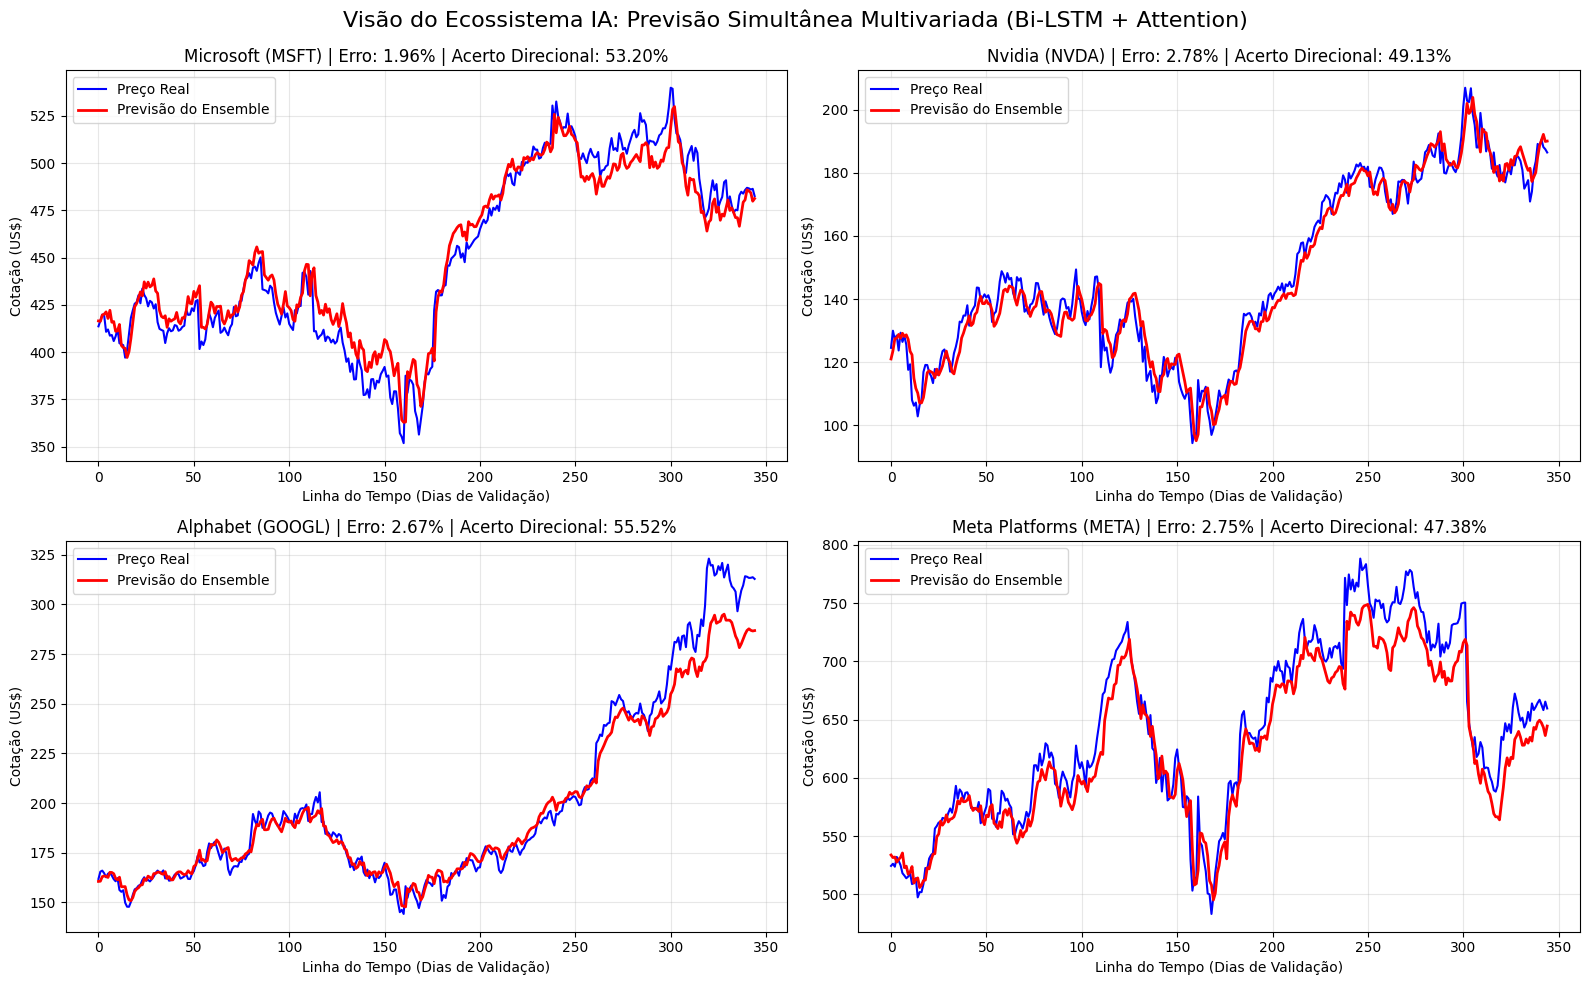

In [4]:
# 4.1. Cálculo Matemático de Avaliação
mapes = []
hit_rates = []
nomes_ativos = ['Microsoft (MSFT)', 'Nvidia (NVDA)', 'Alphabet (GOOGL)', 'Meta Platforms (META)']

print("\n" + "="*60)
print(" RESULTADO OFICIAL - ARQUITETURA DEFINTIVA (2.000 MODELOS)")
print("="*60)

for i in range(QTD_ALVOS):
    real_ativo = reais_em_dolar[:, i]
    prev_ativo = media_previsoes_teste[:, i]
    
    # MAPE
    mape_ativo = np.mean(np.abs((real_ativo - prev_ativo) / (real_ativo + 1e-8))) * 100
    mapes.append(mape_ativo)
    
    # Hit Rate
    acertos = 0
    total_dias = len(real_ativo) - 1
    
    for dia in range(1, len(real_ativo)):
        movimento_real = real_ativo[dia] - real_ativo[dia-1]
        movimento_previsto = prev_ativo[dia] - real_ativo[dia-1]
        
        if (movimento_real > 0 and movimento_previsto > 0) or (movimento_real < 0 and movimento_previsto < 0):
            acertos += 1
            
    hit_rate_ativo = (acertos / total_dias) * 100
    hit_rates.append(hit_rate_ativo)
    
    print(f"{nomes_ativos[i]}:")
    print(f"  - MAPE: {mape_ativo:.2f}%")
    print(f"  - Hit Rate (Direção Correta): {hit_rate_ativo:.2f}%\n")

print("-" * 60)
print(f"MAPE GLOBAL DO ECOSSISTEMA: {np.mean(mapes):.2f}%")
print(f"HIT RATE MÉDIO DO PORTFÓLIO: {np.mean(hit_rates):.2f}%")
print("="*60)

# 4.2. Exportação de Dados para Excel/CSV
df_resultados = pd.DataFrame({'Dia_do_Teste': range(1, len(reais_em_dolar) + 1)})

for i, ativo in enumerate(['MSFT', 'NVDA', 'GOOGL', 'META']):
    df_resultados[f'{ativo}_Real_US$'] = reais_em_dolar[:, i]
    df_resultados[f'{ativo}_Previsto_US$'] = media_previsoes_teste[:, i]

# Salvando no formato brasileiro (separador ; e decimal ,)
df_resultados.to_csv('Resultado_Final_Ecossistema.csv', sep=';', decimal=',', index=False)
print("Planilha CSV (Resultado_Final_Ecossistema.csv) gerada com sucesso.")

# 4.3. Renderização do Painel Gráfico Final
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Visão do Ecossistema IA: Previsão Simultânea Multivariada (Bi-LSTM + Attention)', fontsize=16)

axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    ax.plot(reais_em_dolar[:, i], label='Preço Real', color='blue', linewidth=1.5)
    ax.plot(media_previsoes_teste[:, i], label='Previsão do Ensemble', color='red', linewidth=2)
    
    ax.set_title(f"{nomes_ativos[i]} | Erro: {mapes[i]:.2f}% | Acerto Direcional: {hit_rates[i]:.2f}%")
    ax.set_xlabel('Linha do Tempo (Dias de Validação)')
    ax.set_ylabel('Cotação (US$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.92) 
plt.show()